In [42]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd


In [43]:
# Module 3 Lab
# Generating Data

# Generate 100 random numbers from a normal distribution with mean 5 and standard deviation 1. Make sure to set a random 
# seed so that this computation is reproducible. Use the stats library to generate the data, not numpy.

rng = np.random.default_rng(3)

mu, sigma, n_samples = 5, 1, 100

# Generate the data for a normal distribution
data = stats.norm.rvs(loc=mu, 
                      scale=sigma, 
                      size=n_samples, 
                      random_state=rng)

# Create a dataframe with the data
df = pd.DataFrame(data, columns=['val'])
df

,val
0,7.040919
1,2.444335
2,5.418099
3,4.432230
4,4.547351
...,...
95,3.269987
96,4.995586
97,6.213564
98,5.757058


The mean is 4.9382
The median is 4.9628
The std deviation is 1.0717


<Axes: ylabel='Count'>

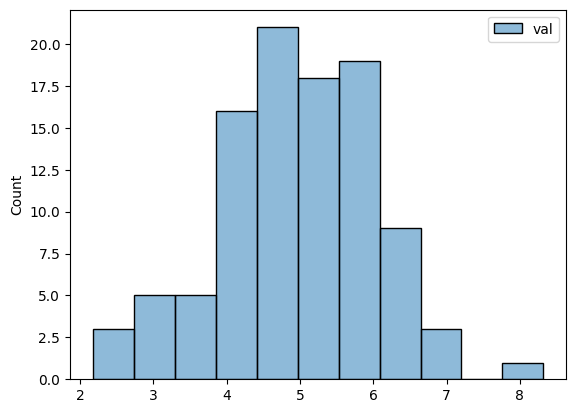

In [44]:
# Investigate your data

# Summary statistics
# Calculate the following summary statistics about the data you generated:
#     What is the mean?
#     What is the median?
#     What is the standard deviation?

# Your code should not only calculate these values, but also print the result for a reader ("The mean is..."; "The median is..."). 
mu = df['val'].mean()
median = df['val'].median()
sigma = df['val'].std()
print(f"The mean is {mu:.4f}")
print(f"The median is {median:.4f}")
print(f"The std deviation is {sigma:.4f}")

# They're close, but they're not exactly the same value as what we used when generating the dataset. And that's because 
# if we are drawing randomly a finite number of points from our data generating process.

sns.histplot(data=df)

In [48]:
# Confidence intervals

# Calculate the following confidence intervals on the data you generated using the percentile method:
    # 90%
    # 95%
    # 99%

lower_bound = stats.scoreatpercentile(df.val, 5)
upper_bound = stats.scoreatpercentile(df.val, 95)
print(f"The 90% Confidence Interval is from {lower_bound:.2f} to {upper_bound:.2f}")

lower_bound = stats.scoreatpercentile(df.val, 2.5)
upper_bound = stats.scoreatpercentile(df.val, 97.5)
print(f"The 95% Confidence Interval is from {lower_bound:.2f} to {upper_bound:.2f}")

lower_bound = stats.scoreatpercentile(df.val, 0.5)
upper_bound = stats.scoreatpercentile(df.val, 99.5)
print(f"The 99% Confidence Interval is from {lower_bound:.2f} to {upper_bound:.2f}")


The 90% Confidence Interval is from 2.98 to 6.55
The 95% Confidence Interval is from 2.67 to 6.81
The 99% Confidence Interval is from 2.31 to 7.69


<Axes: xlabel='val', ylabel='Density'>

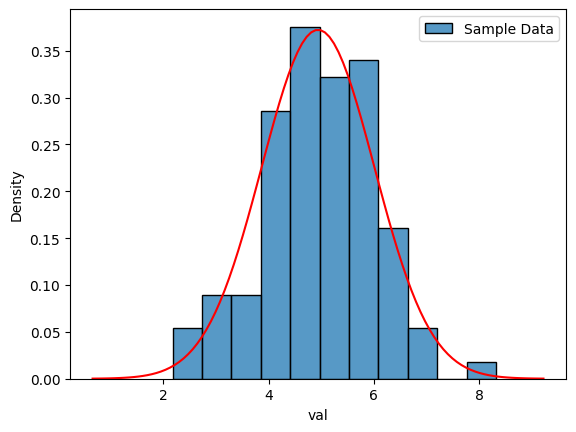

In [49]:
m = df['val'].mean()
s = df['val'].std()

x = np.linspace(m - 4*s, m + 4*s, 100)
y = stats.norm.pdf(x, m, s)
pdf = pd.DataFrame({"val": x, "probability": y})

sns.histplot(df['val'], stat='density', label='Sample Data') # must specify stat='density' to have a normalized plot
sns.lineplot(data=pdf, x='val', y='probability', color='red')

In [50]:

lower_bound = stats.scoreatpercentile(pdf.val, 16)
upper_bound = stats.scoreatpercentile(pdf.val, 84)
print(f"The 68% Confidence Interval is from {lower_bound:.2f} to {upper_bound:.2f}")

lower_bound = stats.scoreatpercentile(pdf.val, 2.5)
upper_bound = stats.scoreatpercentile(pdf.val, 97.5)
print(f"The 95% Confidence Interval is from {lower_bound:.2f} to {upper_bound:.2f}")

lower_bound = stats.scoreatpercentile(pdf.val, 0.5)
upper_bound = stats.scoreatpercentile(pdf.val, 99.5)
print(f"The 99% Confidence Interval is from {lower_bound:.2f} to {upper_bound:.2f}")



The 68% Confidence Interval is from 2.02 to 7.85
The 95% Confidence Interval is from 0.87 to 9.01
The 99% Confidence Interval is from 0.69 to 9.18
